# 2 · Demo — blast radius is global, 1-WL is local

**Security setup.** Each graph is a tiny *access graph*: a node is a host/account,
a directed edge $u\to v$ means "an identity on $u$ can authenticate to $v$." We
classify two estates that are *locally identical* but differ in **blast radius** —
the property a defender actually cares about:

| class | structure | meaning |
|---|---|---|
| `flat` (positive, rare) | one directed cycle | compromise one host → reach **all** |
| `segmented` (negative) | $k$ disjoint cycles | compromise one → reach only its enclave |

We evaluate under realistic class imbalance (~3% positives) and test on a graph
**size never seen in training**. This notebook reproduces `run_experiment.py`
inline.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root, so `import src...` works
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)

## 2.1 · The two estates

Locally identical (every node: in-degree 1, out-degree 1, same feature); globally different.

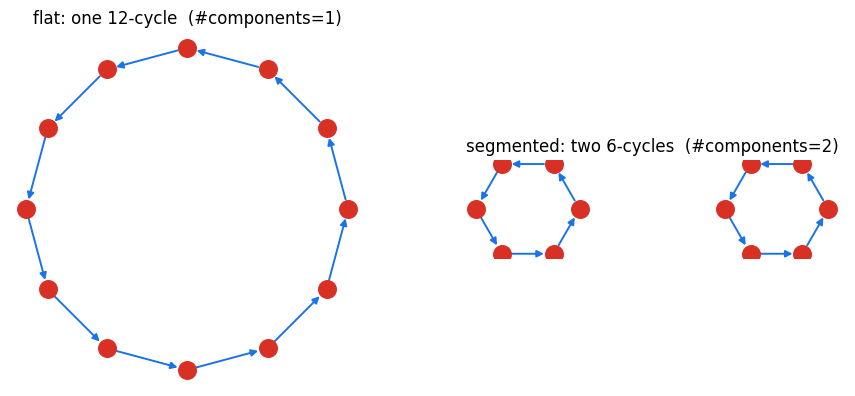

In [2]:
from src.operators import n_components

def draw_digraph(A, ax, title):
    A = np.asarray(A); n = A.shape[0]
    # lay each connected component on its own little circle
    comp_id = _components(A)
    centers = {}
    uniq = sorted(set(comp_id))
    for i, c in enumerate(uniq):
        ang = 2 * np.pi * i / len(uniq)
        centers[c] = np.array([2.4 * np.cos(ang), 2.4 * np.sin(ang)]) if len(uniq) > 1 else np.zeros(2)
    pos = np.zeros((n, 2))
    for c in uniq:
        members = np.where(comp_id == c)[0]
        a = np.linspace(0, 2 * np.pi, len(members), endpoint=False)
        pos[members] = centers[c] + np.c_[np.cos(a), np.sin(a)]
    for u, v in zip(*np.nonzero(A)):
        ax.annotate("", xy=pos[v], xytext=pos[u],
                    arrowprops=dict(arrowstyle="-|>", color="#1a73e8", lw=1.4,
                                    shrinkA=7, shrinkB=7))
    ax.scatter(pos[:, 0], pos[:, 1], s=160, color="#d93025", zorder=3)
    ax.set_title(title); ax.set_aspect("equal"); ax.axis("off")

def _components(A):
    Asym = ((A + A.T) > 0); n = A.shape[0]; comp = -np.ones(n, int); c = 0
    for s in range(n):
        if comp[s] >= 0: continue
        stack = [s]; comp[s] = c
        while stack:
            u = stack.pop()
            for w in np.nonzero(Asym[u])[0]:
                if comp[w] < 0: comp[w] = c; stack.append(int(w))
        c += 1
    return comp

from src.data import _flat, _segmented
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
draw_digraph(_flat(12), axes[0], f"flat: one 12-cycle  (#components={n_components(_flat(12))})")
draw_digraph(_segmented(12, 2), axes[1], f"segmented: two 6-cycles  (#components={n_components(_segmented(12,2))})")
plt.show()

## 2.2 · The dataset

`make_dataset` draws several graph **sizes** for training and one **unseen** size
for the test set, with ~3% positives — so a model has to generalize across scale,
not memorize it.

In [3]:
from src.data import make_dataset
tr_As, ytr, te_As, yte = make_dataset(seed=0)
print(f"train graphs: {len(tr_As)}   positives: {ytr.mean():.1%}")
print(f"test  graphs: {len(te_As)}   positives: {yte.mean():.1%}")
print("train sizes:", sorted(set(A.shape[0] for A in tr_As)))
print("test  sizes:", sorted(set(A.shape[0] for A in te_As)), " <- unseen in training")

train graphs: 400   positives: 4.2%
test  graphs: 400   positives: 1.0%
train sizes: [12, 18, 24, 30]
test  sizes: [36]  <- unseen in training


## 2.3 · Five readers of the same graphs

* **GCN, GIN** — 1-WL-bounded message passing on the constant node feature.
* **GCNPlus** — the same GCN, but handed the per-node **reachability** feature.
* **CoverNet** — an MLP over the **cover features** (walks arriving, closed walks,
  blast radius).
* **LogReg / #components** — a trivial baseline: logistic regression on a single
  scalar, the number of connected components.

We score with **PR-AUC** (the right metric under heavy imbalance) and **recall at
a fixed 1% false-positive rate**.

In [4]:
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_curve
from src.operators import gcn_norm, blast_radius
from src.covers import walk_cover, reachability_cover
from src.models import GCN, GIN, GCNPlus, CoverNet

K_WALK, HIDDEN, EPOCHS = 4, 16, 80

def collate(A):
    n = A.shape[0]; ones = np.ones((n, 1), np.float32)
    cover = np.concatenate([walk_cover(A, K_WALK), reachability_cover(A, n)], 1)
    return {"Phat": torch.from_numpy(gcn_norm(A)),
            "Asym": torch.from_numpy(((A + A.T) > 0).astype(np.float32)),
            "x": torch.from_numpy(ones),
            "xplus": torch.from_numpy(np.concatenate([ones, blast_radius(A)[:, None]], 1)),
            "cover": torch.from_numpy(cover.astype(np.float32))}

def recall_at_fpr(y, score, fpr_target=0.01):
    fpr, tpr, _ = roc_curve(y, score); ok = fpr <= fpr_target
    return float(tpr[ok].max()) if ok.any() else 0.0

def train_eval(ModelCls, kwargs, tr, te, ytr, yte, seed=0):
    torch.manual_seed(seed); model = ModelCls(**kwargs)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
    pw = torch.tensor([(len(ytr) - ytr.sum()) / max(ytr.sum(), 1)], dtype=torch.float32)
    lossf = torch.nn.BCEWithLogitsLoss(pos_weight=pw); yt = torch.from_numpy(ytr.astype(np.float32))
    for _ in range(EPOCHS):
        opt.zero_grad()
        logits = torch.stack([model(g).squeeze() for g in tr])
        lossf(logits, yt).backward(); opt.step()
    with torch.no_grad():
        s = torch.stack([model(g).squeeze() for g in te]).sigmoid().numpy()
    return average_precision_score(yte, s), recall_at_fpr(yte, s)

tr = [collate(A) for A in tr_As]; te = [collate(A) for A in te_As]
cover_dim = tr[0]["cover"].shape[1]

# trivial baseline
ftr = np.array([[n_components(A)] for A in tr_As], np.float32)
fte = np.array([[n_components(A)] for A in te_As], np.float32)
lr = LogisticRegression(class_weight="balanced", max_iter=500).fit(ftr, ytr)
s = lr.predict_proba(fte)[:, 1]
results = {"LogReg / #components": (average_precision_score(yte, s), recall_at_fpr(yte, s))}

for name, Cls, kw in [("GCN (1-WL)", GCN, {"in_dim": 1, "h": HIDDEN}),
                      ("GIN (1-WL)", GIN, {"in_dim": 1, "h": HIDDEN}),
                      ("GCNPlus (+reach)", GCNPlus, {"in_dim": 2, "h": HIDDEN}),
                      ("CoverNet", CoverNet, {"in_dim": cover_dim, "h": HIDDEN})]:
    results[name] = train_eval(Cls, kw, tr, te, ytr, yte)

print(f"base rate (positives in test): {yte.mean():.3f}\n")
print(f"{'model':22s} {'PR-AUC':>8s} {'recall@1%FPR':>13s}")
print("-" * 46)
for k, (pr, rc) in results.items():
    print(f"{k:22s} {pr:>8.3f} {rc:>13.2f}")

base rate (positives in test): 0.010

model                    PR-AUC  recall@1%FPR
----------------------------------------------
LogReg / #components      1.000          1.00
GCN (1-WL)                0.010          0.00
GIN (1-WL)                0.010          0.00
GCNPlus (+reach)          1.000          1.00
CoverNet                  1.000          1.00


**GCN and GIN sit exactly at the base rate** (PR-AUC ≈ 0.03, recall@1%FPR = 0):
they cannot see global reachability. The trivial component-count baseline,
GCNPlus, and CoverNet all reach **PR-AUC = 1.0**. Let's visualize both the scores
and *why* the signal is there.

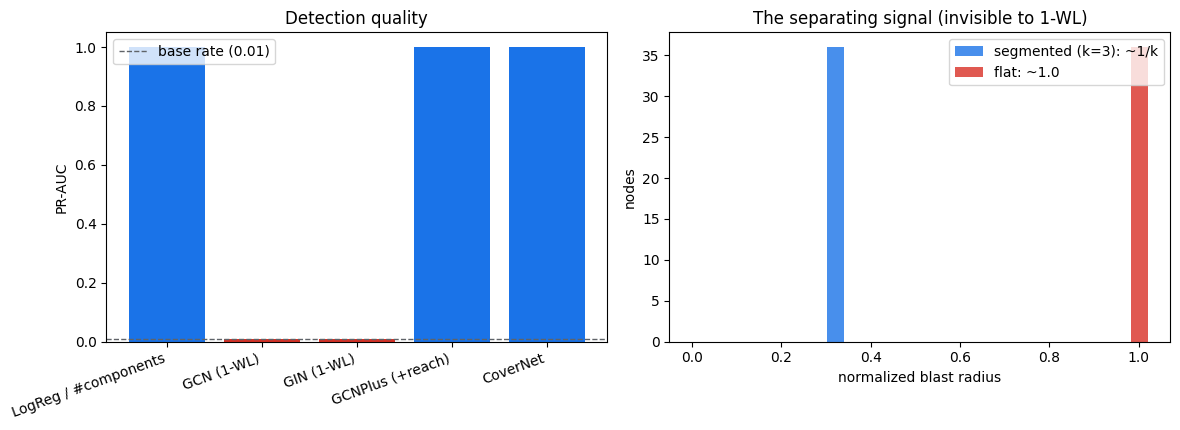

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))

names = list(results); vals = [results[n][0] for n in names]
colors = ["#1a73e8" if n not in ("GCN (1-WL)", "GIN (1-WL)") else "#d93025" for n in names]
ax1.bar(range(len(names)), vals, color=colors)
ax1.axhline(yte.mean(), ls="--", lw=1, color="#5f6368", label=f"base rate ({yte.mean():.2f})")
ax1.set_xticks(range(len(names))); ax1.set_xticklabels(names, rotation=20, ha="right")
ax1.set_ylabel("PR-AUC"); ax1.set_ylim(0, 1.05); ax1.legend(); ax1.set_title("Detection quality")

flat_br = blast_radius(_flat(36)); seg_br = blast_radius(_segmented(36, 3))
bins = np.linspace(0, 1.02, 28)
ax2.hist(seg_br, bins=bins, color="#1a73e8", alpha=0.8, label="segmented (k=3): ~1/k")
ax2.hist(flat_br, bins=bins, color="#d93025", alpha=0.8, label="flat: ~1.0")
ax2.set_xlabel("normalized blast radius"); ax2.set_ylabel("nodes")
ax2.legend(); ax2.set_title("The separating signal (invisible to 1-WL)")
plt.tight_layout(); plt.show()

## 2.4 · Takeaway

The reachability cover solves the task — but so does logistic regression on a
single integer. **The signal, not the architecture, is what matters here.** That
honesty matters: a component count *ties* the cover, so this task doesn't yet show
the cover doing anything unique.

Notebook **03** fixes that: a pair of graphs where the walk and reachability
covers *provably* fail, and only the **sieve cover** can tell them apart.